# Figure 4: Large-scale Scalability with CELLxGENE Datasets

New core figure for the benchmark paper. Shows CrossCell's scalability
from 10k to 1.2M cells using 11 CELLxGENE datasets.

| Panel | Content |
|---|---|
| **4A** | Dataset landscape (bubble chart: cells vs file size, colored by tissue) |
| **4B** | Conversion time vs cell count (H5AD→RDS and RDS→H5AD) |
| **4C** | Peak memory vs cell count (with 16GB/128GB reference lines) |
| **4D** | Performance summary table (color-coded) |

**Data source**: `cellxgene_scalability.json` (128GB server).


In [1]:
import warnings
warnings.filterwarnings('ignore')

import json, os, re, subprocess, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path('/benchmark/results')
DATA_DIR = Path('/benchmark/data/generated')
FIGURES_DIR_MAIN = Path('/benchmark/figures/main')
FIGURES_DIR_SUPP = Path('/benchmark/figures/supplementary')
TMP_DIR = Path('/tmp/notebook_work')

for d in [RESULTS_DIR, FIGURES_DIR_MAIN, FIGURES_DIR_SUPP, TMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 10, 'axes.labelsize': 11,
    'axes.titlesize': 12, 'figure.dpi': 150,
    'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

COLORS = {
    'CrossCell': '#025e8d', 'Zellkonverter': '#f58220',
    'anndataR': '#00a69d', 'convert2anndata': '#785ba7',
    'easySCF': '#c75301',
    'success': '#00a69d', 'failed': '#be1818', 'na': '#999999',
}

ALL_TOOLS = ['CrossCell', 'Zellkonverter', 'anndataR', 'convert2anndata', 'easySCF']

def extract_error_reason(stderr_text):
    """Extract a short error reason from R/tool stderr output."""
    if not stderr_text:
        return 'unknown error'
    for line in stderr_text.split('\n'):
        line = line.strip()
        if line.startswith('Error') or 'error' in line.lower():
            return line[:120] + ('...' if len(line) > 120 else '')
    lines = [l.strip() for l in stderr_text.strip().split('\n') if l.strip()]
    if lines:
        return lines[-1][:120]
    return 'unknown error'

FIGURES_DIR = FIGURES_DIR_MAIN

print('✅ Environment setup complete')


✅ Environment setup complete


## 1. Load CELLxGENE Test Results

In [2]:
SCALABILITY_JSON = RESULTS_DIR / 'cellxgene_scalability.json'

def load_from_scalability_json(path):
    with open(path) as f:
        data = json.load(f)
    datasets = []
    tissue_map = {
        'skin_bcc_10k':'skin','tabula_liver_22k':'liver','kidney_atacseq_37k':'kidney',
        'brain_multiome_102k':'brain','pancreas_122k':'pancreas','brain_dlpfc_172k':'brain',
        'gut_428k':'gut','heart_486k':'heart','hlca_core_585k':'lung',
        'combat_pbmc_836k':'blood','eqtl_autoimmune_1.2M':'blood',
    }
    sparsity_map = {
        'skin_bcc_10k': 93.1, 'tabula_liver_22k': 95.4, 'kidney_atacseq_37k': 69.4,
        'brain_multiome_102k': 93.2, 'pancreas_122k': 96.0, 'brain_dlpfc_172k': 91.9,
        'gut_428k': 94.6, 'heart_486k': 96.1, 'hlca_core_585k': 95.0,
        'combat_pbmc_836k': 95.0, 'eqtl_autoimmune_1.2M': 95.0,
    }
    for r in data.get('results', []):
        h2r = r.get('h5ad_to_rds', {})
        r2h = r.get('rds_to_h5ad', {})
        peak = max(h2r.get('peak_mem_mb',0), r2h.get('peak_mem_mb',0),
                   r.get('inspect',{}).get('peak_mem_mb',0))
        status = 'success'
        if h2r.get('status')=='failed' or r2h.get('status')=='failed': status='partial'
        if h2r.get('status')=='skipped': status='skipped'
        h2r_s = h2r.get('time_s') if h2r.get('status')=='success' else None
        r2h_s = r2h.get('time_s') if r2h.get('status')=='success' else None
        datasets.append({
            'name': r['name'], 'cells': r['cells'], 'genes': r['genes'],
            'tissue': tissue_map.get(r['name'], 'unknown'),
            'file_mb': r.get('file_mb', 0),
            'sparsity': sparsity_map.get(r['name'], 95.0),
            'h2r_s': h2r_s, 'r2h_s': r2h_s,
            'peak_mem_gb': round(peak/1024, 2) if peak else None,
            'rds_mb': h2r.get('rds_mb'),
            'rt_h5ad_mb': r2h.get('h5ad_mb'),
            'env': data.get('metadata',{}).get('machine','128GB'),
            'status': status,
        })
    return datasets


if SCALABILITY_JSON.exists():
    DATASETS = load_from_scalability_json(SCALABILITY_JSON)
    print(f"Loaded {len(DATASETS)} datasets from {SCALABILITY_JSON}")
else:
    print(f"{SCALABILITY_JSON} not found, using hardcoded fallback")
    DATASETS_FALLBACK = [
        # ── 16GB local machine (verified from test_results.json) ──
        {"name": "skin_bcc_10k", "cells": 9841, "genes": 26886, "tissue": "skin",
         "file_mb": 89, "sparsity": 93.1, "h2r_s": 24.5, "r2h_s": 4.3,
         "peak_mem_gb": 0.86, "rds_mb": 44, "env": "16GB", "status": "success"},
        {"name": "tabula_liver_22k", "cells": 22214, "genes": 60606, "tissue": "liver",
         "file_mb": 796, "sparsity": 95.4, "h2r_s": 361.8, "r2h_s": 56.5,
         "peak_mem_gb": 2.03, "rds_mb": 712, "env": "16GB", "status": "success"},
        {"name": "kidney_atacseq_37k", "cells": 37747, "genes": 19276, "tissue": "kidney",
         "file_mb": 898, "sparsity": 69.4, "h2r_s": 358.2, "r2h_s": 85.9,
         "peak_mem_gb": 4.5, "rds_mb": 543, "env": "16GB", "status": "success"},
        {"name": "brain_multiome_102k", "cells": 101924, "genes": 35451, "tissue": "brain",
         "file_mb": 1142, "sparsity": 93.2, "h2r_s": 376.1, "r2h_s": 83.4,
         "peak_mem_gb": 5.2, "rds_mb": 632, "env": "16GB", "status": "success"},
        {"name": "pancreas_122k", "cells": 121916, "genes": 32356, "tissue": "pancreas",
         "file_mb": 915, "sparsity": 96.0, "h2r_s": 215.6, "r2h_s": 44.5,
         "peak_mem_gb": 2.48, "rds_mb": 354, "env": "16GB", "status": "success"},
        # ── 64GB server (from cellxgene_scalability.json) ──
        {"name": "brain_dlpfc_172k", "cells": 172120, "genes": 37490, "tissue": "brain",
         "file_mb": 2234, "sparsity": 91.9, "h2r_s": 1412.4, "r2h_s": 130.6,
         "peak_mem_gb": 30.1, "rds_mb": 1263, "env": "64GB", "status": "success"},
        {"name": "gut_428k", "cells": 428469, "genes": 32383, "tissue": "gut",
         "file_mb": 5462, "sparsity": 94.6, "h2r_s": 2704.8, "r2h_s": 219.5,
         "peak_mem_gb": 44.0, "rds_mb": 4304, "env": "64GB", "status": "success"},
        {"name": "heart_486k", "cells": 486134, "genes": 32383, "tissue": "heart",
         "file_mb": 2816, "sparsity": 96.1, "h2r_s": 1740.7, "r2h_s": 165.6,
         "peak_mem_gb": 35.9, "rds_mb": 1485, "env": "64GB", "status": "success"},
        {"name": "hlca_core_585k", "cells": 584944, "genes": 27402, "tissue": "lung",
         "file_mb": 5602, "sparsity": 95.0, "h2r_s": 3323.6, "r2h_s": 346.2,
         "peak_mem_gb": 63.3, "rds_mb": 2910, "env": "64GB", "status": "success"},
        {"name": "combat_pbmc_836k", "cells": 836148, "genes": 36306, "tissue": "blood",
         "file_mb": 5337, "sparsity": 95.0, "h2r_s": 3215.8, "r2h_s": 324.5,
         "peak_mem_gb": 63.4, "rds_mb": 2633, "env": "64GB", "status": "success"},
        # ── 64GB x79 server — million-scale ──
        {"name": "eqtl_autoimmune_1.2M", "cells": 1248980, "genes": 35528, "tissue": "blood",
         "file_mb": 4229, "sparsity": 95.0, "h2r_s": 3612.3, "r2h_s": 442.3,
         "peak_mem_gb": 63.4, "rds_mb": 3969, "env": "64GB", "status": "success"},
    ]
    DATASETS = DATASETS_FALLBACK

df = pd.DataFrame(DATASETS)
print(f"Total datasets: {len(df)}")
print(f"Cell range: {df['cells'].min():,} - {df['cells'].max():,}")


Loaded 11 datasets from /benchmark/results/cellxgene_scalability.json
Total datasets: 11
Cell range: 9,841 - 1,248,980


## 2. Fig 4A: Time Breakdown (Stacked Bar)


Saved fig4a_time_breakdown


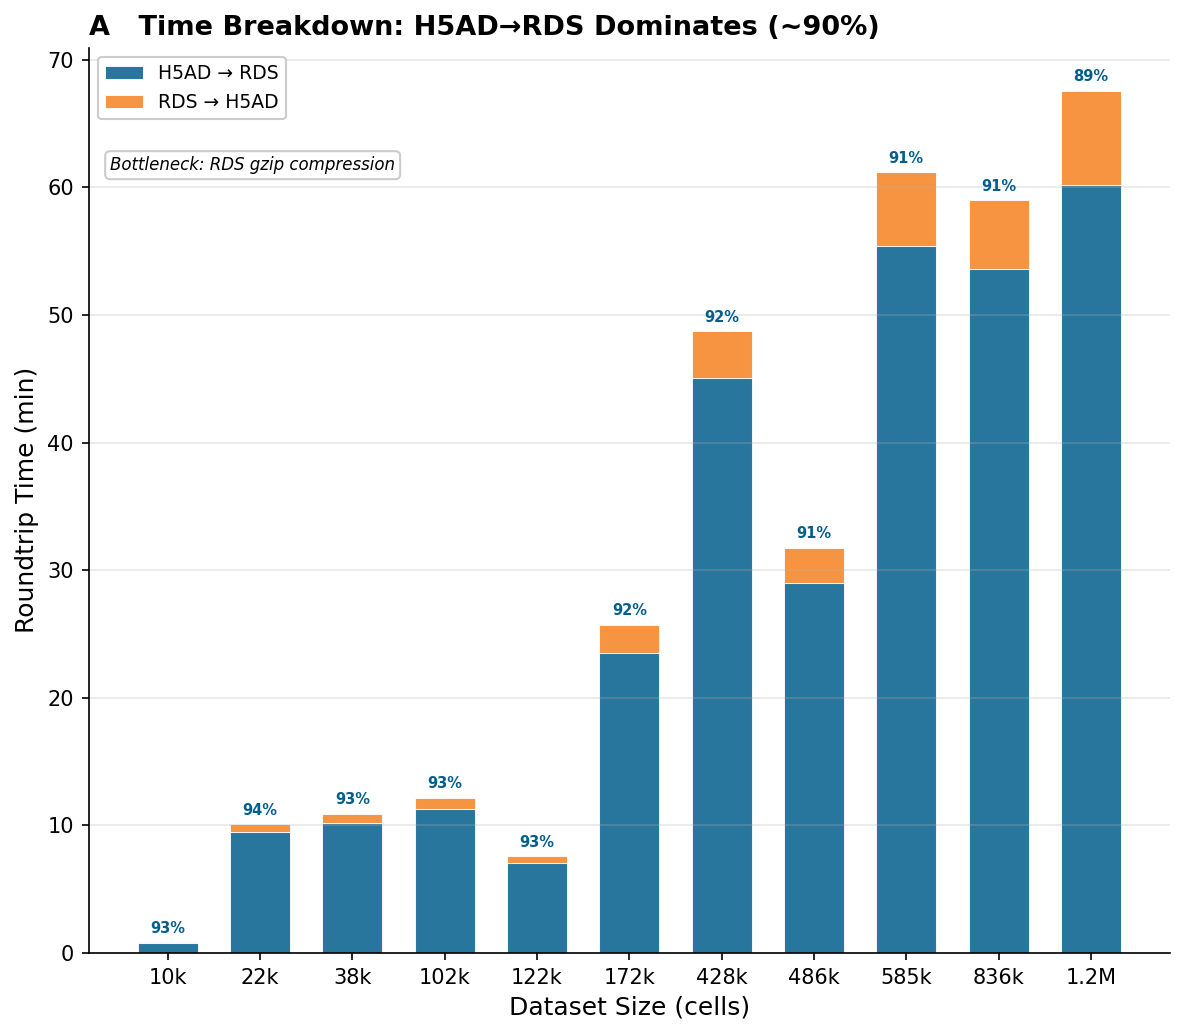

In [3]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import stats

LABEL_SIZE = 12
TITLE_SIZE = 13
TICK_SIZE = 10
LEGEND_SIZE = 9
ANNOT_SIZE = 8
NOTE_SIZE = 8

fig, ax_a = plt.subplots(figsize=(8, 7))

df_time = df.dropna(subset=['h2r_s', 'r2h_s']).copy()
df_time = df_time.sort_values('cells')
df_time['total_s'] = df_time['h2r_s'] + df_time['r2h_s']
df_time['h2r_pct'] = df_time['h2r_s'] / df_time['total_s'] * 100

x_a = np.arange(len(df_time))
labels_a = []
for _, row in df_time.iterrows():
    c = row['cells']
    if c >= 1e6:
        labels_a.append(f"{c/1e6:.1f}M")
    else:
        labels_a.append(f"{c/1e3:.0f}k")

h2r_min = df_time['h2r_s'].values / 60
r2h_min = df_time['r2h_s'].values / 60

bars_h2r = ax_a.bar(x_a, h2r_min, 0.65, color='#025e8d', alpha=0.85,
                    label='H5AD \u2192 RDS', edgecolor='white', linewidth=0.5)
bars_r2h = ax_a.bar(x_a, r2h_min, 0.65, bottom=h2r_min, color='#f58220', alpha=0.85,
                    label='RDS \u2192 H5AD', edgecolor='white', linewidth=0.5)

for i, (_, row) in enumerate(df_time.iterrows()):
    total_min = (row['h2r_s'] + row['r2h_s']) / 60
    ax_a.text(i, total_min + 0.5, f"{row['h2r_pct']:.0f}%",
             ha='center', va='bottom', fontsize=7, color='#025e8d', fontweight='bold')

ax_a.set_xticks(x_a)
ax_a.set_xticklabels(labels_a, fontsize=ANNOT_SIZE)
ax_a.set_xlabel('Dataset Size (cells)', fontsize=LABEL_SIZE)
ax_a.set_ylabel('Roundtrip Time (min)', fontsize=LABEL_SIZE)
ax_a.set_title('A   Time Breakdown: H5AD\u2192RDS Dominates (~90%)',
               fontweight='bold', loc='left', fontsize=TITLE_SIZE)

ax_a.legend(loc='upper left', fontsize=LEGEND_SIZE,
            facecolor='white', edgecolor='#cccccc', framealpha=1)
ax_a.text(0.02, 0.88, 'Bottleneck: RDS gzip compression',
          transform=ax_a.transAxes, fontsize=NOTE_SIZE, style='italic',
          va='top', ha='left',
          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc'))

ax_a.tick_params(labelsize=TICK_SIZE)
ax_a.grid(axis='y', alpha=0.3)
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig4a_time_breakdown.pdf')
fig.savefig(FIGURES_DIR / 'fig4a_time_breakdown.png')
print('Saved fig4a_time_breakdown')
plt.show()


## 3. Fig 4B: Memory vs Cell Count (Scatter + Fit)


Saved fig4b_memory_vs_cells


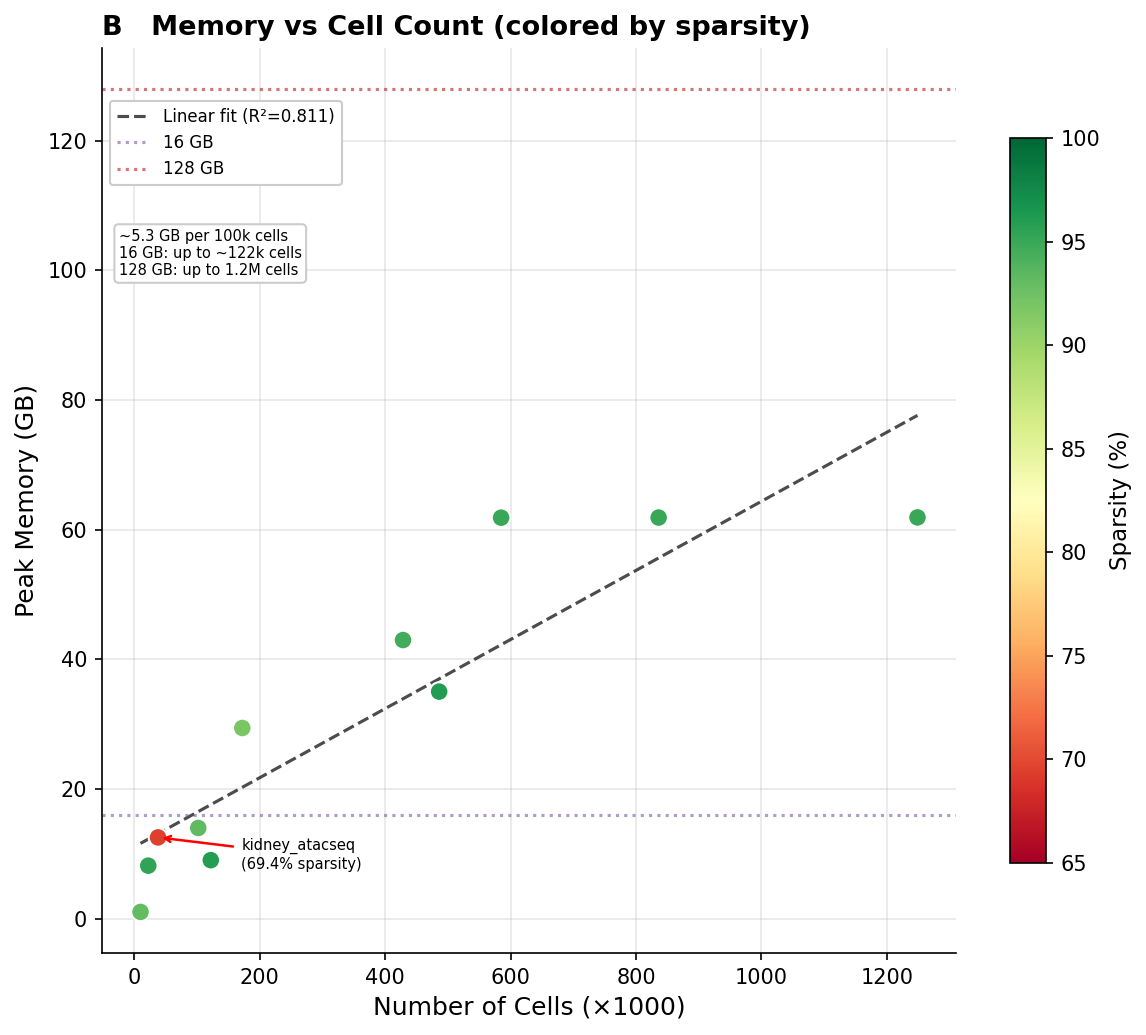

In [4]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import stats

LABEL_SIZE = 12
TITLE_SIZE = 13
TICK_SIZE = 10
LEGEND_SIZE = 9
ANNOT_SIZE = 8
NOTE_SIZE = 8

fig, ax_b = plt.subplots(figsize=(8, 7))

df_mem = df.dropna(subset=['peak_mem_gb']).copy()

sc = ax_b.scatter(df_mem['cells'] / 1e3, df_mem['peak_mem_gb'], s=80,
                  c=df_mem['sparsity'], cmap='RdYlGn', vmin=65, vmax=100,
                  edgecolor='white', linewidth=1, zorder=3)

x_fit = df_mem['cells'].values / 1e3
y_fit = df_mem['peak_mem_gb'].values
slope, intercept, r_value, _, _ = stats.linregress(x_fit, y_fit)
x_line = np.linspace(x_fit.min(), x_fit.max(), 100)
ax_b.plot(x_line, slope * x_line + intercept, 'k--', linewidth=1.5, alpha=0.7,
          label=f'Linear fit (R\u00b2={r_value**2:.3f})')

ax_b.axhline(y=16, color='#785ba7', linestyle=':', linewidth=1.5, alpha=0.6, label='16 GB')
ax_b.axhline(y=128, color='#be1818', linestyle=':', linewidth=1.5, alpha=0.6, label='128 GB')

kidney = df_mem[df_mem['name'] == 'kidney_atacseq_37k']
if len(kidney) > 0:
    k = kidney.iloc[0]
    ax_b.annotate(f'kidney_atacseq\n(69.4% sparsity)',
                  (k['cells'] / 1e3, k['peak_mem_gb']),
                  fontsize=7, xytext=(40, -15), textcoords='offset points',
                  arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

ax_b.set_xlabel('Number of Cells (\u00d71000)', fontsize=LABEL_SIZE)
ax_b.set_ylabel('Peak Memory (GB)', fontsize=LABEL_SIZE)
ax_b.set_title('B   Memory vs Cell Count (colored by sparsity)',
               fontweight='bold', loc='left', fontsize=TITLE_SIZE)

gb_per_100k = slope * 100
ax_b.legend(bbox_to_anchor=(0, 0.95), loc='upper left', fontsize=LEGEND_SIZE - 1,
            facecolor='white', edgecolor='#cccccc', framealpha=1,
            bbox_transform=ax_b.transAxes)
note_b_text = (f'~{gb_per_100k:.1f} GB per 100k cells\n'
               f'16 GB: up to ~122k cells\n'
               f'128 GB: up to 1.2M cells')
ax_b.text(0.02, 0.8, note_b_text,
          transform=ax_b.transAxes, fontsize=NOTE_SIZE - 1,
          va='top', ha='left',
          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc'))

plt.colorbar(sc, ax=ax_b, label='Sparsity (%)', shrink=0.8)
ax_b.tick_params(labelsize=TICK_SIZE)
ax_b.grid(alpha=0.3)
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig4b_memory_vs_cells.pdf')
fig.savefig(FIGURES_DIR / 'fig4b_memory_vs_cells.png')
print('Saved fig4b_memory_vs_cells')
plt.show()


## 4. Fig 4C: File Size Comparison (Grouped Bar)


Saved fig4c_file_size_comparison


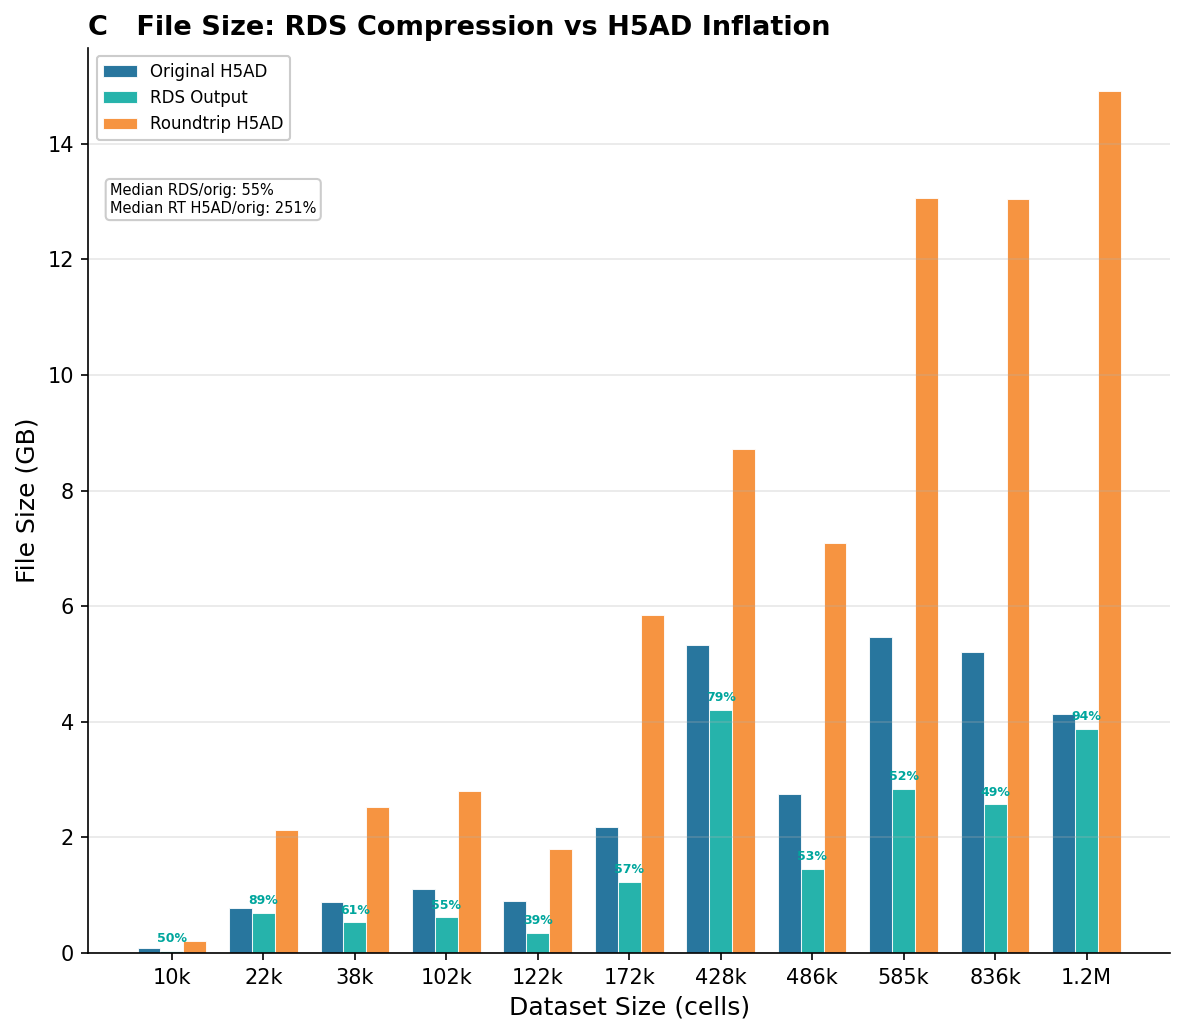

In [5]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import stats

LABEL_SIZE = 12
TITLE_SIZE = 13
TICK_SIZE = 10
LEGEND_SIZE = 9
ANNOT_SIZE = 8
NOTE_SIZE = 8

fig, ax_c = plt.subplots(figsize=(8, 7))

df_fs = df.dropna(subset=['rds_mb', 'rt_h5ad_mb']).copy()
df_fs = df_fs.sort_values('cells')

x_c = np.arange(len(df_fs))
w = 0.25
labels_c = []
for _, row in df_fs.iterrows():
    c = row['cells']
    if c >= 1e6:
        labels_c.append(f"{c/1e6:.1f}M")
    else:
        labels_c.append(f"{c/1e3:.0f}k")

orig_gb = df_fs['file_mb'].values / 1024
rds_gb = df_fs['rds_mb'].values / 1024
rt_gb = df_fs['rt_h5ad_mb'].values / 1024

ax_c.bar(x_c - w, orig_gb, w, color='#025e8d', alpha=0.85,
         label='Original H5AD', edgecolor='white', linewidth=0.5)
ax_c.bar(x_c, rds_gb, w, color='#00a69d', alpha=0.85,
         label='RDS Output', edgecolor='white', linewidth=0.5)
ax_c.bar(x_c + w, rt_gb, w, color='#f58220', alpha=0.85,
         label='Roundtrip H5AD', edgecolor='white', linewidth=0.5)

for i, (_, row) in enumerate(df_fs.iterrows()):
    ratio = row['rds_mb'] / row['file_mb'] * 100
    ax_c.text(i, rds_gb[i] + 0.1, f"{ratio:.0f}%",
             ha='center', va='bottom', fontsize=6, color='#00a69d', fontweight='bold')

ax_c.set_xticks(x_c)
ax_c.set_xticklabels(labels_c, fontsize=ANNOT_SIZE)
ax_c.set_xlabel('Dataset Size (cells)', fontsize=LABEL_SIZE)
ax_c.set_ylabel('File Size (GB)', fontsize=LABEL_SIZE)
ax_c.set_title('C   File Size: RDS Compression vs H5AD Inflation',
               fontweight='bold', loc='left', fontsize=TITLE_SIZE)

med_rds_ratio = np.median(df_fs['rds_mb'].values / df_fs['file_mb'].values) * 100
med_rt_ratio = np.median(df_fs['rt_h5ad_mb'].values / df_fs['file_mb'].values) * 100
ax_c.legend(loc='upper left', fontsize=LEGEND_SIZE - 1,
            facecolor='white', edgecolor='#cccccc', framealpha=1)
note_c_text = (f'Median RDS/orig: {med_rds_ratio:.0f}%\n'
               f'Median RT H5AD/orig: {med_rt_ratio:.0f}%')
ax_c.text(0.02, 0.85, note_c_text,
          transform=ax_c.transAxes, fontsize=NOTE_SIZE - 1,
          va='top', ha='left',
          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc'))

ax_c.tick_params(labelsize=TICK_SIZE)
ax_c.grid(axis='y', alpha=0.3)
ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig4c_file_size_comparison.pdf')
fig.savefig(FIGURES_DIR / 'fig4c_file_size_comparison.png')
print('Saved fig4c_file_size_comparison')
plt.show()


## 5. Fig 4D: Memory Amplification Factor


Saved fig4d_memory_amplification


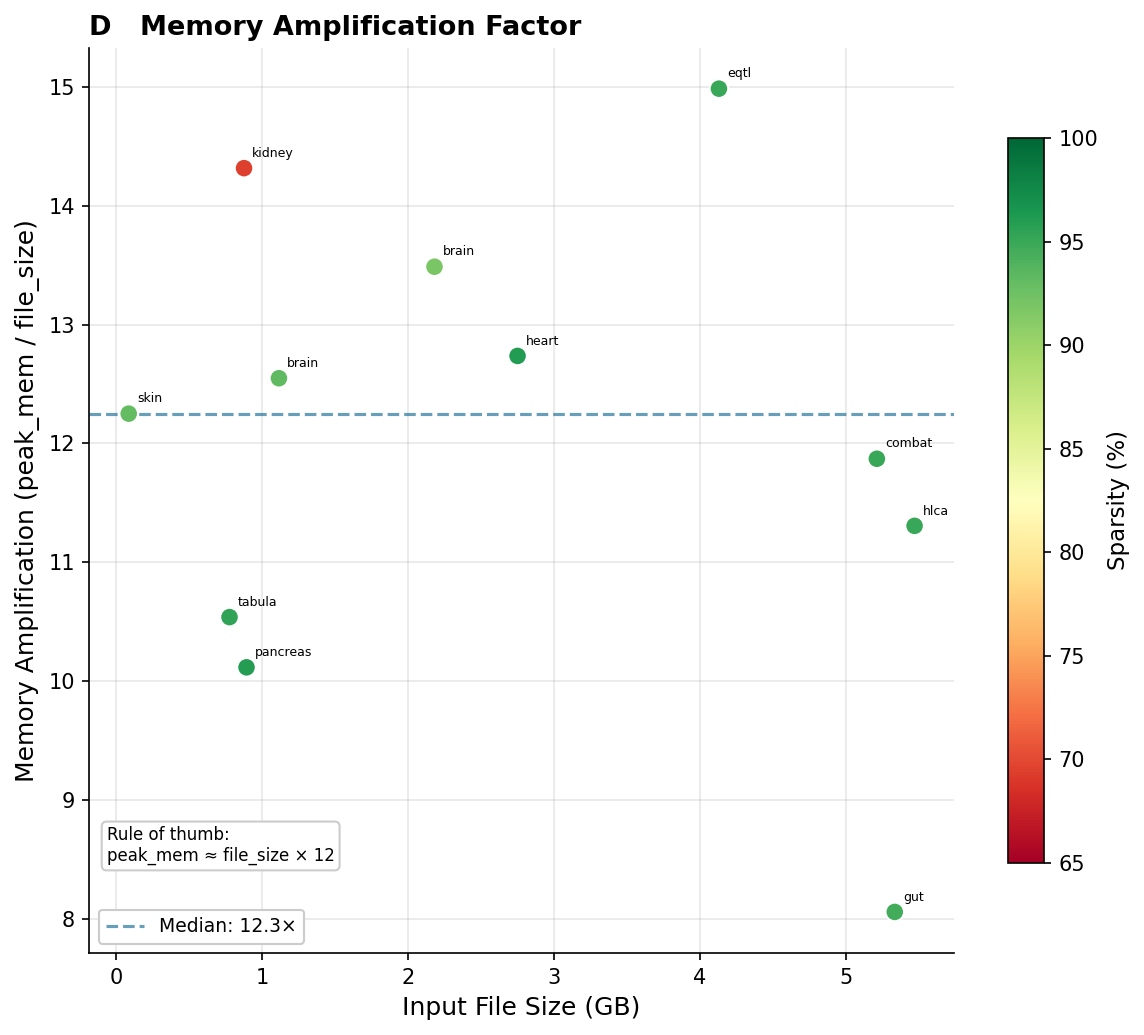

In [6]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import stats

LABEL_SIZE = 12
TITLE_SIZE = 13
TICK_SIZE = 10
LEGEND_SIZE = 9
ANNOT_SIZE = 8
NOTE_SIZE = 8

fig, ax_d = plt.subplots(figsize=(8, 7))

df_amp = df.dropna(subset=['peak_mem_gb']).copy()
df_amp['file_gb'] = df_amp['file_mb'] / 1024
df_amp['mem_amp'] = df_amp['peak_mem_gb'] / df_amp['file_gb']

sc_d = ax_d.scatter(df_amp['file_gb'], df_amp['mem_amp'], s=80,
                    c=df_amp['sparsity'], cmap='RdYlGn', vmin=65, vmax=100,
                    edgecolor='white', linewidth=1, zorder=3)

for _, row in df_amp.iterrows():
    short_name = row['name'].split('_')[0]
    ax_d.annotate(short_name, (row['file_gb'], row['mem_amp']),
                  fontsize=6, ha='left', va='bottom', xytext=(4, 4),
                  textcoords='offset points')

med_amp = df_amp['mem_amp'].median()
ax_d.axhline(y=med_amp, color='#025e8d', linestyle='--', linewidth=1.5, alpha=0.6,
             label=f'Median: {med_amp:.1f}\u00d7')

ax_d.set_xlabel('Input File Size (GB)', fontsize=LABEL_SIZE)
ax_d.set_ylabel('Memory Amplification (peak_mem / file_size)', fontsize=LABEL_SIZE)
ax_d.set_title('D   Memory Amplification Factor',
               fontweight='bold', loc='left', fontsize=TITLE_SIZE)

ax_d.legend(loc='lower left', fontsize=LEGEND_SIZE,
            facecolor='white', edgecolor='#cccccc', framealpha=1)
note_d_text = (f'Rule of thumb:\n'
               f'peak_mem \u2248 file_size \u00d7 {med_amp:.0f}')
ax_d.text(0.02, 0.14, note_d_text,
          transform=ax_d.transAxes, fontsize=NOTE_SIZE,
          va='top', ha='left',
          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc'))

plt.colorbar(sc_d, ax=ax_d, label='Sparsity (%)', shrink=0.8)
ax_d.tick_params(labelsize=TICK_SIZE)
ax_d.grid(alpha=0.3)
ax_d.spines['top'].set_visible(False)
ax_d.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig4d_memory_amplification.pdf')
fig.savefig(FIGURES_DIR / 'fig4d_memory_amplification.png')
print('Saved fig4d_memory_amplification')
plt.show()


## 6. Composite Figure 4 (A+B+C+D)

Saved fig4_scalability_composite


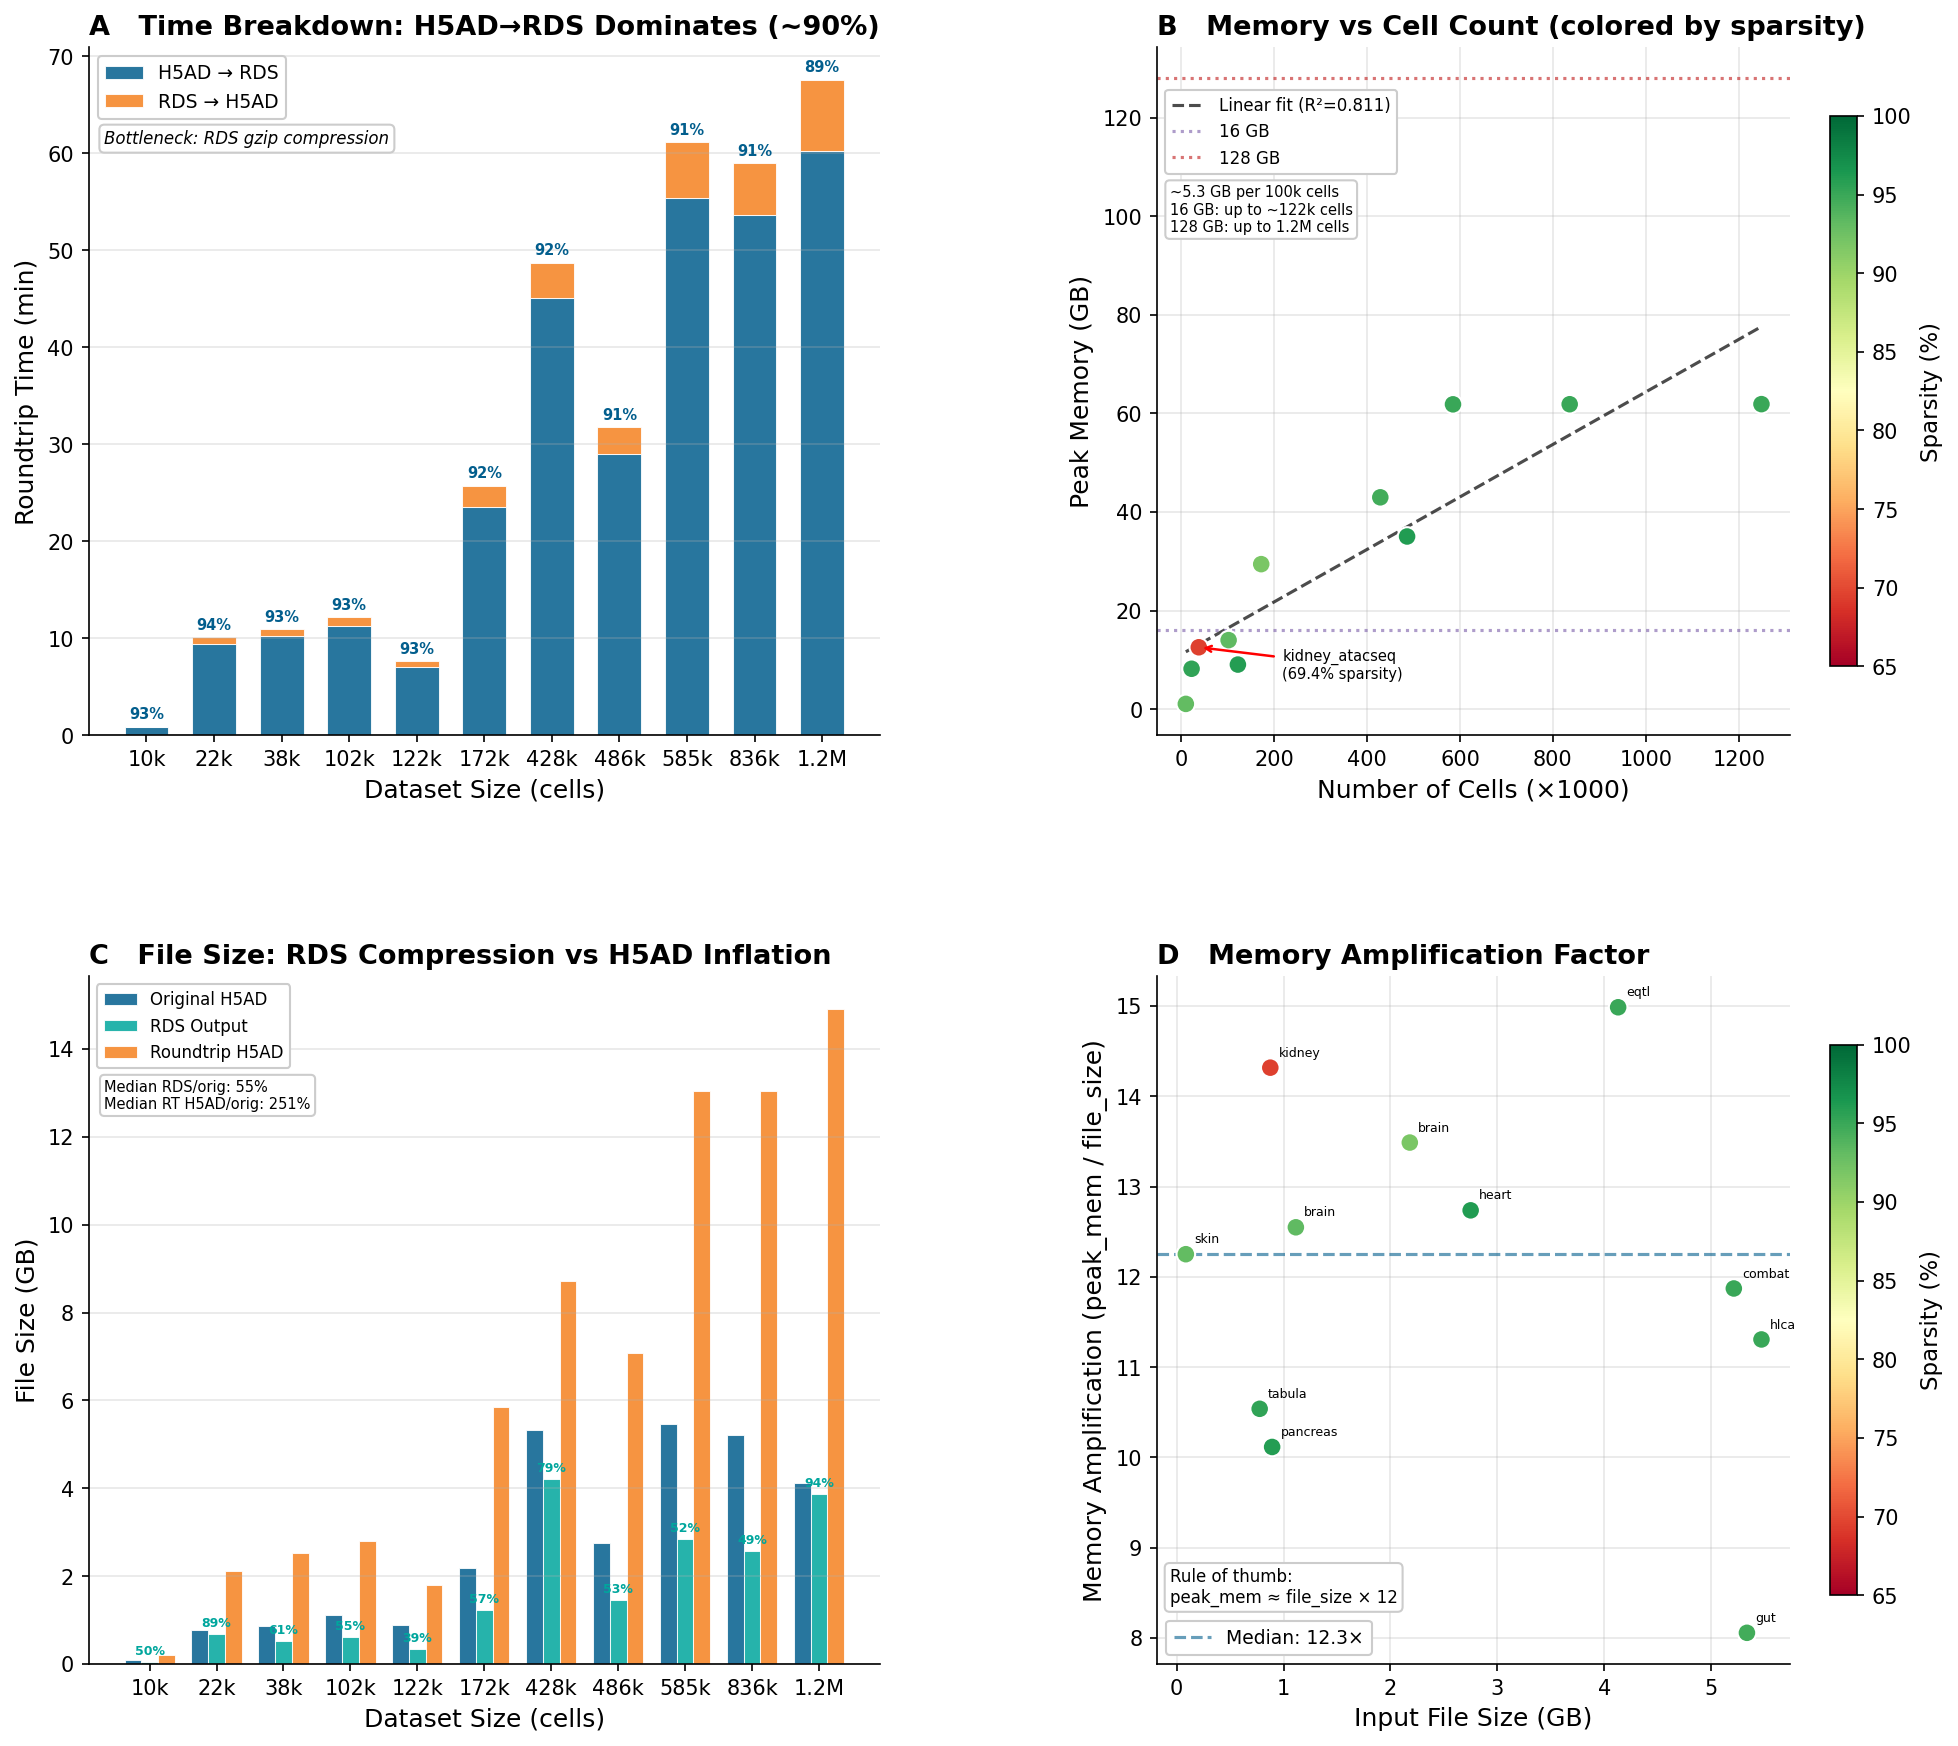

In [7]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import stats

LABEL_SIZE = 12
TITLE_SIZE = 13
TICK_SIZE = 10
LEGEND_SIZE = 9
ANNOT_SIZE = 8
NOTE_SIZE = 8

fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.35)

# ============================================================
# Panel A: Time Breakdown (Stacked Bar)
# ============================================================
ax_a = fig.add_subplot(gs[0, 0])

df_time = df.dropna(subset=['h2r_s', 'r2h_s']).copy()
df_time = df_time.sort_values('cells')
df_time['total_s'] = df_time['h2r_s'] + df_time['r2h_s']
df_time['h2r_pct'] = df_time['h2r_s'] / df_time['total_s'] * 100

x_a = np.arange(len(df_time))
labels_a = []
for _, row in df_time.iterrows():
    c = row['cells']
    if c >= 1e6:
        labels_a.append(f"{c/1e6:.1f}M")
    else:
        labels_a.append(f"{c/1e3:.0f}k")

h2r_min = df_time['h2r_s'].values / 60
r2h_min = df_time['r2h_s'].values / 60

bars_h2r = ax_a.bar(x_a, h2r_min, 0.65, color='#025e8d', alpha=0.85,
                    label='H5AD \u2192 RDS', edgecolor='white', linewidth=0.5)
bars_r2h = ax_a.bar(x_a, r2h_min, 0.65, bottom=h2r_min, color='#f58220', alpha=0.85,
                    label='RDS \u2192 H5AD', edgecolor='white', linewidth=0.5)

for i, (_, row) in enumerate(df_time.iterrows()):
    total_min = (row['h2r_s'] + row['r2h_s']) / 60
    ax_a.text(i, total_min + 0.5, f"{row['h2r_pct']:.0f}%",
             ha='center', va='bottom', fontsize=7, color='#025e8d', fontweight='bold')

ax_a.set_xticks(x_a)
ax_a.set_xticklabels(labels_a, fontsize=ANNOT_SIZE)
ax_a.set_xlabel('Dataset Size (cells)', fontsize=LABEL_SIZE)
ax_a.set_ylabel('Roundtrip Time (min)', fontsize=LABEL_SIZE)
ax_a.set_title('A   Time Breakdown: H5AD\u2192RDS Dominates (~90%)',
               fontweight='bold', loc='left', fontsize=TITLE_SIZE)

# Data legend only
ax_a.legend(loc='upper left', fontsize=LEGEND_SIZE,
            facecolor='white', edgecolor='#cccccc', framealpha=1)
# Separate note box below legend (x=0.02 aligns with legend left edge)
ax_a.text(0.02, 0.88, 'Bottleneck: RDS gzip compression',
          transform=ax_a.transAxes, fontsize=NOTE_SIZE, style='italic',
          va='top', ha='left',
          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc'))

ax_a.tick_params(labelsize=TICK_SIZE)
ax_a.grid(axis='y', alpha=0.3)
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)

# ============================================================
# Panel B: Peak Memory vs Cell Count (Scatter + Fit)
# ============================================================
ax_b = fig.add_subplot(gs[0, 1])

df_mem = df.dropna(subset=['peak_mem_gb']).copy()

sc = ax_b.scatter(df_mem['cells'] / 1e3, df_mem['peak_mem_gb'], s=80,
                  c=df_mem['sparsity'], cmap='RdYlGn', vmin=65, vmax=100,
                  edgecolor='white', linewidth=1, zorder=3)

x_fit = df_mem['cells'].values / 1e3
y_fit = df_mem['peak_mem_gb'].values
slope, intercept, r_value, _, _ = stats.linregress(x_fit, y_fit)
x_line = np.linspace(x_fit.min(), x_fit.max(), 100)
ax_b.plot(x_line, slope * x_line + intercept, 'k--', linewidth=1.5, alpha=0.7,
          label=f'Linear fit (R\u00b2={r_value**2:.3f})')

ax_b.axhline(y=16, color='#785ba7', linestyle=':', linewidth=1.5, alpha=0.6, label='16 GB')
ax_b.axhline(y=128, color='#be1818', linestyle=':', linewidth=1.5, alpha=0.6, label='128 GB')

kidney = df_mem[df_mem['name'] == 'kidney_atacseq_37k']
if len(kidney) > 0:
    k = kidney.iloc[0]
    ax_b.annotate(f'kidney_atacseq\n(69.4% sparsity)',
                  (k['cells'] / 1e3, k['peak_mem_gb']),
                  fontsize=7, xytext=(40, -15), textcoords='offset points',
                  arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

ax_b.set_xlabel('Number of Cells (\u00d71000)', fontsize=LABEL_SIZE)
ax_b.set_ylabel('Peak Memory (GB)', fontsize=LABEL_SIZE)
ax_b.set_title('B   Memory vs Cell Count (colored by sparsity)',
               fontweight='bold', loc='left', fontsize=TITLE_SIZE)

# Data legend only
gb_per_100k = slope * 100
ax_b.legend(bbox_to_anchor=(0, 0.95), loc='upper left', fontsize=LEGEND_SIZE - 1,
            facecolor='white', edgecolor='#cccccc', framealpha=1,
            bbox_transform=ax_b.transAxes)
# Separate note box below legend
note_b_text = (f'~{gb_per_100k:.1f} GB per 100k cells\n'
               f'16 GB: up to ~122k cells\n'
               f'128 GB: up to 1.2M cells')
ax_b.text(0.02, 0.8, note_b_text,
          transform=ax_b.transAxes, fontsize=NOTE_SIZE - 1,
          va='top', ha='left',
          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc'))

plt.colorbar(sc, ax=ax_b, label='Sparsity (%)', shrink=0.8)
ax_b.tick_params(labelsize=TICK_SIZE)
ax_b.grid(alpha=0.3)
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)

# ============================================================
# Panel C: File Size Comparison (Grouped Bar)
# ============================================================
ax_c = fig.add_subplot(gs[1, 0])

df_fs = df.dropna(subset=['rds_mb', 'rt_h5ad_mb']).copy()
df_fs = df_fs.sort_values('cells')

x_c = np.arange(len(df_fs))
w = 0.25
labels_c = []
for _, row in df_fs.iterrows():
    c = row['cells']
    if c >= 1e6:
        labels_c.append(f"{c/1e6:.1f}M")
    else:
        labels_c.append(f"{c/1e3:.0f}k")

orig_gb = df_fs['file_mb'].values / 1024
rds_gb = df_fs['rds_mb'].values / 1024
rt_gb = df_fs['rt_h5ad_mb'].values / 1024

ax_c.bar(x_c - w, orig_gb, w, color='#025e8d', alpha=0.85,
         label='Original H5AD', edgecolor='white', linewidth=0.5)
ax_c.bar(x_c, rds_gb, w, color='#00a69d', alpha=0.85,
         label='RDS Output', edgecolor='white', linewidth=0.5)
ax_c.bar(x_c + w, rt_gb, w, color='#f58220', alpha=0.85,
         label='Roundtrip H5AD', edgecolor='white', linewidth=0.5)

for i, (_, row) in enumerate(df_fs.iterrows()):
    ratio = row['rds_mb'] / row['file_mb'] * 100
    ax_c.text(i, rds_gb[i] + 0.1, f"{ratio:.0f}%",
             ha='center', va='bottom', fontsize=6, color='#00a69d', fontweight='bold')

ax_c.set_xticks(x_c)
ax_c.set_xticklabels(labels_c, fontsize=ANNOT_SIZE)
ax_c.set_xlabel('Dataset Size (cells)', fontsize=LABEL_SIZE)
ax_c.set_ylabel('File Size (GB)', fontsize=LABEL_SIZE)
ax_c.set_title('C   File Size: RDS Compression vs H5AD Inflation',
               fontweight='bold', loc='left', fontsize=TITLE_SIZE)

# Data legend only
med_rds_ratio = np.median(df_fs['rds_mb'].values / df_fs['file_mb'].values) * 100
med_rt_ratio = np.median(df_fs['rt_h5ad_mb'].values / df_fs['file_mb'].values) * 100
ax_c.legend(loc='upper left', fontsize=LEGEND_SIZE - 1,
            facecolor='white', edgecolor='#cccccc', framealpha=1)
# Separate note box below legend
note_c_text = (f'Median RDS/orig: {med_rds_ratio:.0f}%\n'
               f'Median RT H5AD/orig: {med_rt_ratio:.0f}%')
ax_c.text(0.02, 0.85, note_c_text,
          transform=ax_c.transAxes, fontsize=NOTE_SIZE - 1,
          va='top', ha='left',
          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc'))

ax_c.tick_params(labelsize=TICK_SIZE)
ax_c.grid(axis='y', alpha=0.3)
ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)

# ============================================================
# Panel D: Memory Amplification Factor
# ============================================================
ax_d = fig.add_subplot(gs[1, 1])

df_amp = df.dropna(subset=['peak_mem_gb']).copy()
df_amp['file_gb'] = df_amp['file_mb'] / 1024
df_amp['mem_amp'] = df_amp['peak_mem_gb'] / df_amp['file_gb']

sc_d = ax_d.scatter(df_amp['file_gb'], df_amp['mem_amp'], s=80,
                    c=df_amp['sparsity'], cmap='RdYlGn', vmin=65, vmax=100,
                    edgecolor='white', linewidth=1, zorder=3)

for _, row in df_amp.iterrows():
    short_name = row['name'].split('_')[0]
    ax_d.annotate(short_name, (row['file_gb'], row['mem_amp']),
                  fontsize=6, ha='left', va='bottom', xytext=(4, 4),
                  textcoords='offset points')

med_amp = df_amp['mem_amp'].median()
ax_d.axhline(y=med_amp, color='#025e8d', linestyle='--', linewidth=1.5, alpha=0.6,
             label=f'Median: {med_amp:.1f}\u00d7')

ax_d.set_xlabel('Input File Size (GB)', fontsize=LABEL_SIZE)
ax_d.set_ylabel('Memory Amplification (peak_mem / file_size)', fontsize=LABEL_SIZE)
ax_d.set_title('D   Memory Amplification Factor',
               fontweight='bold', loc='left', fontsize=TITLE_SIZE)

# Data legend only
ax_d.legend(loc='lower left', fontsize=LEGEND_SIZE,
            facecolor='white', edgecolor='#cccccc', framealpha=1)
# Separate note box above legend (lower left area)
note_d_text = (f'Rule of thumb:\n'
               f'peak_mem \u2248 file_size \u00d7 {med_amp:.0f}')
ax_d.text(0.02, 0.14, note_d_text,
          transform=ax_d.transAxes, fontsize=NOTE_SIZE,
          va='top', ha='left',
          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc'))

plt.colorbar(sc_d, ax=ax_d, label='Sparsity (%)', shrink=0.8)
ax_d.tick_params(labelsize=TICK_SIZE)
ax_d.grid(alpha=0.3)
ax_d.spines['top'].set_visible(False)
ax_d.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig4_scalability_composite.pdf')
fig.savefig(FIGURES_DIR / 'fig4_scalability_composite.png')
print('Saved fig4_scalability_composite')
plt.show()
